# Predicting AI Integration Readiness and Challenge Risk in Australian Retail Business Operations

**Student:** Bikash Poudel  
**Research design:** Published secondary-data analysis  
**Analytical tools:** Python, scikit-learn, matplotlib and Power BI-ready data tables

This notebook analyses published, non-identifiable secondary data. The principal observations come from official Australian Bureau of Statistics (ABS) data cubes and time-series workbooks. A published National AI Centre SME survey summary is used for contextual triangulation. Journal articles may interpret the findings, but they are not treated as the numerical dataset unless an accessible dataset is supplied.

The notebook does not generate fictional business records. Every direct observation is traceable to a published source. Composite indexes, model predictions and scenarios are explicitly labelled as researcher-created outputs.

## Research questions

1. How did AI use, digital foundations, e-commerce capability, workforce practices and cyber controls change for Retail Trade between 2021-22 and 2024-25?
2. How does Retail Trade compare with other Australian industries on AI adoption and integration challenge exposure?
3. Which published 2021-22 capability indicators are most useful for predicting industry-level AI adoption in 2024-25?
4. What cautious, transparent scenarios can be constructed for future retail AI adoption?
5. What do published retail turnover, industry performance and business survival data reveal about the operating environment in which AI is being integrated?

## Evidence base and source quality

The analysis combines:

- ABS *Characteristics of Australian Business* data cubes for 2021-22 and 2024-25 covering ICT use, skills, internet connectivity, e-commerce, cyber security, finance and innovation;
- ABS monthly *Retail Trade* turnover data;
- ABS *Australian Industry* retail employment and financial time series;
- ABS *Counts of Australian Businesses* data on retail entries, exits and survival;
- the National AI Centre SME AI Pulse published summary for December 2025 to February 2026.

Official source URLs are retained in `data/source_register.csv`. The ABS reports that 12% of all Australian businesses used AI in 2024-25 and 9% of Retail Trade businesses used AI. The National AI Centre reported 43% of surveyed SMEs had some level of AI adoption across December 2025 to February 2026. These figures use different definitions and denominators and are therefore triangulated rather than merged into one outcome variable.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

DATA = Path('data')
industry21 = pd.read_csv(DATA / 'industry_2021_22_expanded.csv')
industry24 = pd.read_csv(DATA / 'industry_2024_25_expanded.csv')
long_data = pd.read_csv(DATA / 'published_secondary_data_long_expanded.csv')
retail_change = pd.read_csv(DATA / 'retail_change_expanded.csv')
challenge = pd.read_csv(DATA / 'ai_integration_readiness_challenge_index.csv')
sensitivity = pd.read_csv(DATA / 'challenge_index_sensitivity.csv')
model_metrics = pd.read_csv(DATA / 'predictive_model_metrics.csv')
model_predictions = pd.read_csv(DATA / 'predictive_model_predictions.csv')
factor_importance = pd.read_csv(DATA / 'predictive_factor_importance.csv')
monthly_turnover = pd.read_csv(DATA / 'retail_monthly_turnover_1982_2025.csv', parse_dates=['date'])
annual_retail = pd.read_csv(DATA / 'retail_annual_industry_performance_2007_2025.csv', parse_dates=['date'])
business_dynamics = pd.read_csv(DATA / 'retail_business_entries_exits_2020_2024.csv')
business_survival = pd.read_csv(DATA / 'retail_business_survival.csv')
naic = pd.read_csv(DATA / 'national_ai_centre_sme_pulse_2025_2026.csv')
scenarios = pd.read_csv(DATA / 'retail_ai_adoption_scenarios_2025_2030.csv')
sources = pd.read_csv(DATA / 'source_register.csv')

print('Industry observations, 2021-22:', industry21.shape)
print('Industry observations, 2024-25:', industry24.shape)
print('Traceable long-format observations:', long_data.shape)
print('Published source entries:', sources.shape[0])

Industry observations, 2021-22: (17, 84)
Industry observations, 2024-25: (17, 144)
Traceable long-format observations: (4114, 13)
Published source entries: 18


## 1. Reproducibility and provenance audit

The long-format file retains the period, industry, variable, published value, source table, source workbook and official source URL. ABS cells marked `np` remain missing and are not changed to zero. Dashes described by ABS as nil or rounded to zero are retained as zero. This distinction prevents suppressed estimates from being treated as observed zeros.

In [2]:
provenance_check = long_data[[
    'period','industry','category','variable','measure','value_pct',
    'publication_flag','source_table','source_file','source_url'
]].sample(12, random_state=42)
provenance_check

,period,industry,category,variable,measure,value_pct,publication_flag,source_table,source_file,source_url
149,2021-22,Health Care and Social Assistance,technology,any_ict_pct,Any ICT used,89.3,published,Table_1,ABS_2021_22_ICT.xlsx,https://www.abs.gov.au/statistics/industry/tec...
166,2021-22,Other Services,technology,data_analytics_pct,Data analytics,3.7,published,Table_1,ABS_2021_22_ICT.xlsx,https://www.abs.gov.au/statistics/industry/tec...
2855,2024-25,Accommodation and Food Services,expanded_context,mobile_5g_pct,5G network,45.6,published,Table 1,ABS_2024_25_Internet_Connectivity_Activities.xlsx,https://www.abs.gov.au/statistics/industry/tec...
811,2024-25,"Electricity, Gas, Water and Waste Services",digital_practice,upgraded_cyber_pct,Upgraded cyber security,23.4,published,Table 1,ABS_2024_25_ICT.xlsx,https://www.abs.gov.au/statistics/industry/tec...
3270,2024-25,"Electricity, Gas, Water and Waste Services",expanded_context,government_wage_cashflow_pct,Wage or cash flow subsidies,4.1,published,Table 1,ABS_2024_25_Business_Finance_Assistance.xlsx,https://www.abs.gov.au/statistics/industry/tec...
1765,2024-25,Wholesale Trade,business_environment,input_cost_barrier_pct,Input cost barrier,30.2,published,Table 6,ABS_2024_25_Business_Profile_Practices_Perform...,https://www.abs.gov.au/statistics/industry/tec...
1509,2024-25,Mining,cyber_governance,identity_access_management_pct,Identity and access management,48.1,published,Table 3,ABS_2024_25_Cyber_Security.xlsx,https://www.abs.gov.au/statistics/industry/tec...
1756,2024-25,Construction,business_environment,input_cost_barrier_pct,Input cost barrier,25.5,published,Table 6,ABS_2024_25_Business_Profile_Practices_Perform...,https://www.abs.gov.au/statistics/industry/tec...
2496,2021-22,"Professional, Scientific and Technical Services",connectivity_ecommerce,internet_sufficient_pct,Sufficient,47.2,published,Table_4,ABS_2021_22_Internet_Connectivity.xlsx,https://www.abs.gov.au/statistics/industry/tec...
70,2021-22,Accommodation and Food Services,technology,crm_pct,Customer Relationship Management software,7.9,published,Table_1,ABS_2021_22_ICT.xlsx,https://www.abs.gov.au/statistics/industry/tec...


In [3]:
quality = pd.DataFrame({
    'records':[len(long_data)],
    'published_values':[long_data['value_pct'].notna().sum()],
    'missing_or_not_published':[long_data['value_pct'].isna().sum()],
    'industries':[long_data['industry'].nunique()],
    'variables':[long_data['variable'].nunique()],
    'source_files':[long_data['source_file'].nunique()]
})
quality

,records,published_values,missing_or_not_published,industries,variables,source_files
0,4114,3969,145,17,155,14


### Interpretation

The expanded audit table contains more than four thousand source-linked observations. Its purpose is not to imply that every measure is directly comparable. Instead, it provides a transparent evidence inventory from which harmonised variables are selected. Percentage measures are only compared when the concept and denominator are sufficiently similar across waves.

## 2. AI adoption accelerated, but Retail Trade remains below the national industry distribution

In [4]:
adoption = industry21[['industry','ai_use_pct']].merge(
    industry24[['industry','ai_use_pct']], on='industry', suffixes=('_2021_22','_2024_25')
)
adoption['change_pp'] = adoption['ai_use_pct_2024_25'] - adoption['ai_use_pct_2021_22']
adoption.sort_values('ai_use_pct_2024_25', ascending=False)

,industry,ai_use_pct_2021_22,ai_use_pct_2024_25,change_pp
9,Information Media and Telecommunications,7.7,38.1,30.4
12,"Professional, Scientific and Technical Services",3.6,24.1,20.5
10,Financial and Insurance Services,0.7,24.1,23.4
1,Mining,1.6,17.8,16.2
14,Health Care and Social Assistance,0.2,17.4,17.2
15,Arts and Recreation Services,1.2,16.5,15.3
3,"Electricity, Gas, Water and Waste Services",1.9,15.4,13.5
5,Wholesale Trade,2.3,13.9,11.6
13,Administrative and Support Services,0.8,12.4,11.6
11,"Rental, Hiring and Real Estate Services",2.5,11.0,8.5


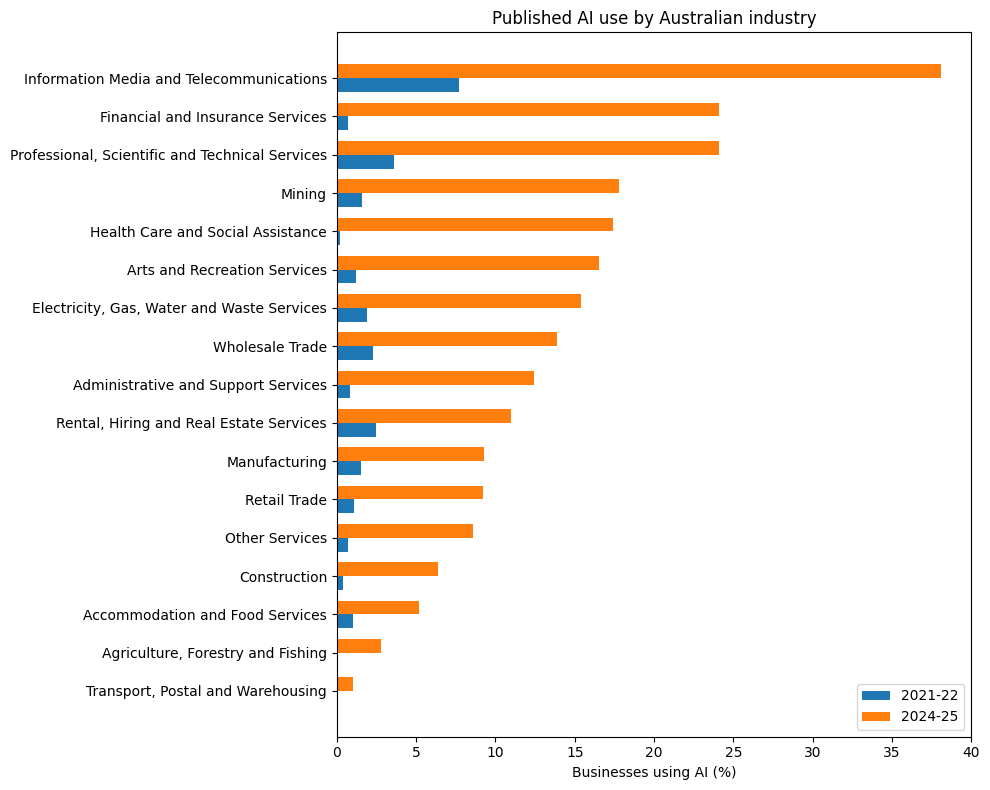

In [5]:
plot = adoption.sort_values('ai_use_pct_2024_25')
y = np.arange(len(plot))
plt.figure(figsize=(10,8))
plt.barh(y-0.18, plot['ai_use_pct_2021_22'], height=0.36, label='2021-22')
plt.barh(y+0.18, plot['ai_use_pct_2024_25'], height=0.36, label='2024-25')
plt.yticks(y, plot['industry'])
plt.xlabel('Businesses using AI (%)')
plt.title('Published AI use by Australian industry')
plt.legend()
plt.tight_layout()
plt.show()

### Finding 1

Retail AI use rose from **1.1%** in 2021-22 to **9.2%** in 2024-25, an increase of **8.1 percentage points**. The increase is substantial relative to the low starting base, but Retail Trade remained well below information-intensive industries. This pattern supports an interpretation of rapid diffusion combined with uneven capability depth.

## 3. Retail digital foundations, e-commerce and connectivity

In [6]:
selected = {
    'ai_use_pct':'AI use',
    'cloud_pct':'Cloud technology',
    'data_analytics_pct':'Data analytics',
    'predictive_analysis_pct':'Predictive analysis',
    'any_online_presence_pct':'Any online presence',
    'any_online_orders_received_pct':'Online orders received',
    'website_app_pct':'Own website or app',
    'fibre_pct':'Fibre connection',
    'mobile_5g_pct':'5G connection',
    'internet_sufficient_pct':'Internet rated sufficient'
}
retail_profile = retail_change[retail_change['variable'].isin(selected)].copy()
retail_profile['measure'] = retail_profile['variable'].map(selected)
retail_profile[['measure','retail_2021_22_pct','retail_2024_25_pct','percentage_point_change']].sort_values('retail_2024_25_pct', ascending=False)

,measure,retail_2021_22_pct,retail_2024_25_pct,percentage_point_change
44,Any online presence,84.3,81.9,-2.4
3,Cloud technology,58.6,67.3,8.7
10,Own website or app,58.1,62.3,4.2
6,Internet rated sufficient,53.2,59.6,6.4
18,Online orders received,52.5,53.1,0.6
0,5G connection,31.4,47.7,16.3
19,Fibre connection,35.7,36.2,0.5
4,AI use,1.1,9.2,8.1
21,Data analytics,6.2,6.6,0.4


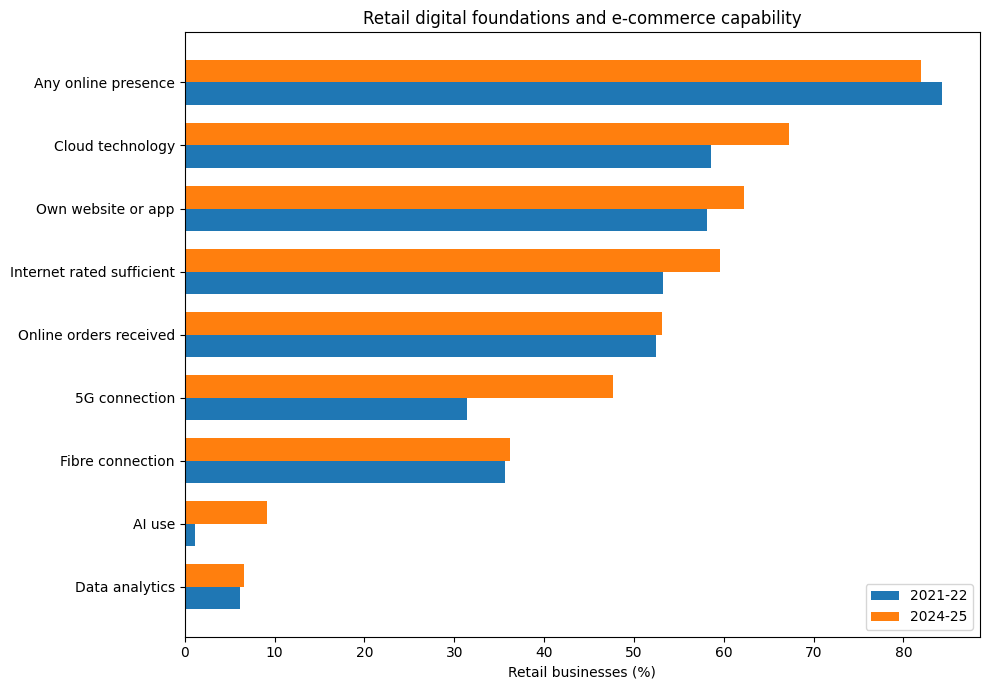

In [7]:
r = retail_profile.sort_values('retail_2024_25_pct')
y = np.arange(len(r))
plt.figure(figsize=(10,7))
plt.barh(y-0.18, r['retail_2021_22_pct'], height=0.36, label='2021-22')
plt.barh(y+0.18, r['retail_2024_25_pct'], height=0.36, label='2024-25')
plt.yticks(y, r['measure'])
plt.xlabel('Retail businesses (%)')
plt.title('Retail digital foundations and e-commerce capability')
plt.legend()
plt.tight_layout()
plt.show()

### Finding 2

Retail has strong customer-facing digital reach: **81.9%** reported an online presence and **53.1%** received internet orders in 2024-25. Cloud use reached 67.3%, while analytical measures remained much lower. This gap is important: an online channel can generate data without automatically creating the governance, integration and analytical capability required for reliable AI.

The greatest comparable increase among the selected connectivity measures was 5G use. Online-order participation was broadly stable, indicating that the major change was not simply more e-commerce; it was the beginning of AI use on top of an already digitised retail channel base.

## 4. Skills, management capability and innovation barriers

In [8]:
retail24 = industry24.set_index('industry').loc['Retail Trade']
workforce = pd.Series({
    'Any ICT limitation': retail24['any_ict_limit_pct'],
    'Insufficient staff skills': retail24['ict_limit_skills_pct'],
    'Cost-benefit uncertainty': retail24['ict_limit_cost_benefit_pct'],
    'Any skill shortage': retail24['any_skill_shortage_pct'],
    'Digital training': retail24['digital_training_pct'],
    'Upskilling/reskilling': retail24['upskilling_reskilling_pct'],
    'Advanced digital recruitment': retail24['recruited_advanced_digital_skills_pct'],
    'Any innovation barrier': retail24['any_innovation_barrier_pct'],
    'Innovation funding barrier': retail24['innovation_barrier_funds_pct'],
    'Innovation cost barrier': retail24['innovation_barrier_cost_pct']
}).sort_values()
workforce.to_frame('retail_2024_25_pct')

,retail_2024_25_pct
Advanced digital recruitment,3.9
Digital training,10.2
Upskilling/reskilling,10.5
Cost-benefit uncertainty,12.6
Innovation cost barrier,15.2
Insufficient staff skills,18.4
Innovation funding barrier,19.2
Any skill shortage,35.6
Any innovation barrier,40.4
Any ICT limitation,42.7


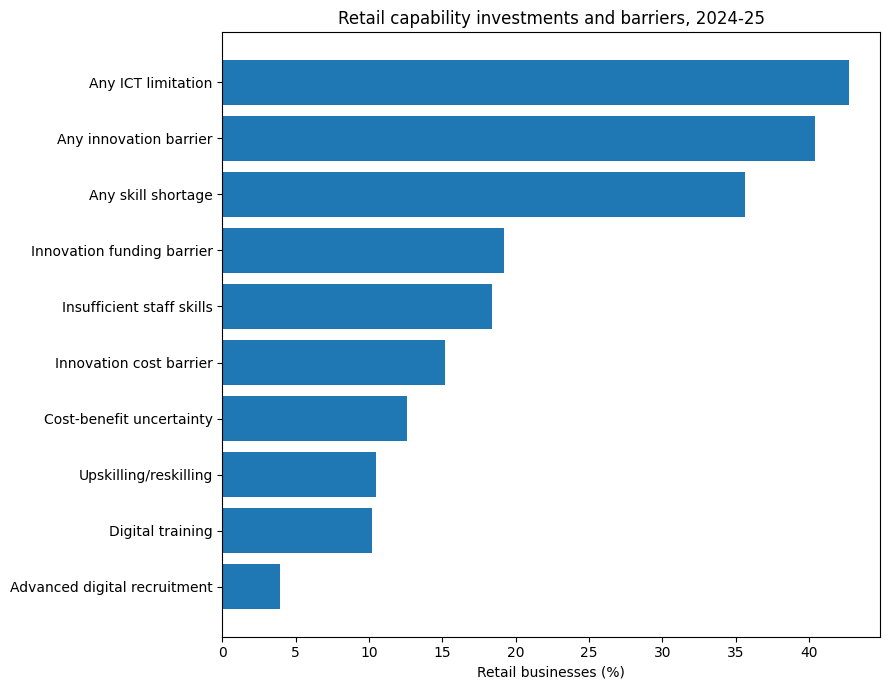

In [9]:
plt.figure(figsize=(9,7))
plt.barh(workforce.index, workforce.values)
plt.xlabel('Retail businesses (%)')
plt.title('Retail capability investments and barriers, 2024-25')
plt.tight_layout()
plt.show()

### Finding 3

**42.7%** of retail businesses reported at least one ICT limitation. Skills remained a central constraint, but only **10.2%** reported new digital training. The imbalance between reported constraints and capability-building activity suggests that AI adoption can spread faster than organisational readiness.

The innovation tables reinforce this conclusion. Retail businesses reported barriers associated with funding, implementation cost, internal skills and uncertain demand. These are not separate from AI integration: they affect whether a retailer can progress from experimentation to scaled operational deployment.

## 5. Cyber exposure and responsible governance

In [10]:
cyber = pd.Series({
    'Any cyber incident': retail24['any_cyber_incident_pct'],
    'Scams or fraud': retail24['scams_fraud_pct'],
    'Malware': retail24['malware_pct'],
    'Any cyber measure': retail24['any_cyber_measure_pct'],
    'Formal cyber policy': retail24['formal_cyber_policy_pct'],
    'Cyber staff training': retail24['cyber_staff_training_pct'],
    'Identity/access management': retail24['identity_access_management_pct'],
    'Security monitoring': retail24['security_monitoring_pct'],
    'Regular backup': retail24['backup_pct']
}).sort_values()
cyber.to_frame('retail_2024_25_pct')

,retail_2024_25_pct
Malware,3.8
Formal cyber policy,9.3
Scams or fraud,15.7
Security monitoring,15.9
Cyber staff training,17.2
Any cyber incident,20.2
Identity/access management,27.3
Regular backup,34.5
Any cyber measure,70.1


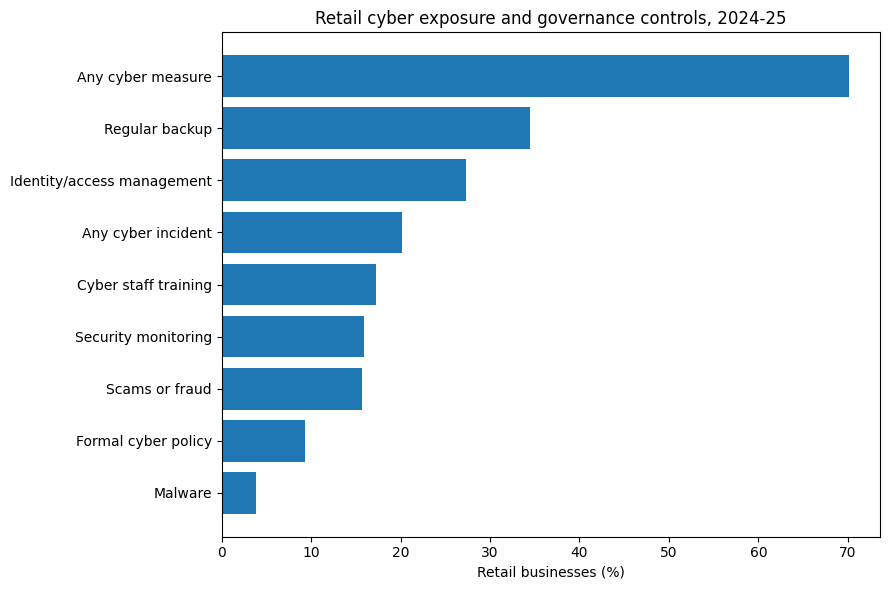

In [11]:
plt.figure(figsize=(9,6))
plt.barh(cyber.index, cyber.values)
plt.xlabel('Retail businesses (%)')
plt.title('Retail cyber exposure and governance controls, 2024-25')
plt.tight_layout()
plt.show()

### Finding 4

One in five retail businesses reported a cyber incident (**20.2%**), yet formal cyber policies and staff training were much less widespread than general technical controls. The distinction matters for AI because access control, auditability, incident escalation and human oversight require formal governance rather than antivirus or backup alone.

The National AI Centre evidence adds a trust dimension. Around 65% of non-adopting SMEs cited distrust of AI decisions or a preference for human control, while approximately half of current users checked outputs before customer impact. Governance is therefore both a risk-control capability and an adoption enabler.

## 6. Innovation benefits, finance and value measurement

In [12]:
innovation = pd.Series({
    'Innovation-active': retail24['innovation_active_pct'],
    'Any innovation benefit': retail24['any_innovation_benefit_pct'],
    'Increased revenue': retail24['innovation_benefit_revenue_pct'],
    'Increased productivity': retail24['innovation_benefit_productivity_pct'],
    'Improved customer service': retail24['innovation_benefit_customer_service_pct'],
    'Too early to measure': retail24['innovation_too_early_pct'],
    'No benefit': retail24['innovation_no_benefit_pct'],
    'Finance sought': retail24['finance_sought_pct'],
    'Finance obtained': retail24['finance_obtained_pct'],
    'Government assistance': retail24['any_government_assistance_pct']
}).sort_values()
innovation.to_frame('retail_2024_25_pct')

,retail_2024_25_pct
Government assistance,7.6
No benefit,13.0
Too early to measure,15.9
Increased productivity,21.3
Finance obtained,21.4
Finance sought,23.3
Improved customer service,30.4
Increased revenue,44.3
Innovation-active,59.4
Any innovation benefit,71.2


### Finding 5

Retail innovation produced reported benefits in revenue, productivity and customer service, but a meaningful group considered it too early to measure outcomes. This supports stage-gated AI investment: use cases should have baseline metrics, benefit owners and review points before scaling. Finance data also indicates that capital access is uneven, so recommendations must distinguish between large retailers with internal data teams and small firms relying on packaged tools or external providers.

## 7. Researcher-created AI Integration Readiness and Challenge Index

The index is a transparent synthesis, not an official ABS indicator. Six dimensions are min-max scaled across 17 industries:

- digital foundation;
- analytical maturity;
- workforce capability;
- governance and resilience;
- innovation and finance capacity;
- barrier pressure.

The principal weighting gives 20% to analytical maturity, 20% to workforce capability, 20% to barrier pressure, 15% to digital foundation, 15% to governance and 10% to innovation/finance capacity. Sensitivity analysis tests equal, capability-emphasised and risk-emphasised alternatives.

In [13]:
challenge.sort_values('challenge_index', ascending=False)[[
    'industry','digital_foundation','analytical_maturity','workforce_capability',
    'governance_resilience','innovation_finance_capacity','barrier_pressure',
    'readiness_index','challenge_index','challenge_rank_1_highest','class'
]]

,industry,digital_foundation,analytical_maturity,workforce_capability,governance_resilience,innovation_finance_capacity,barrier_pressure,readiness_index,challenge_index,challenge_rank_1_highest,class
0,"Agriculture, Forestry and Fishing",14.551501,14.775006,1.007412,31.573814,75.524954,65.096493,24.608478,75.391522,1,D - very high challenge
4,Construction,47.475320,8.317952,14.174855,14.065917,35.124763,55.255703,26.191083,73.808917,2,D - very high challenge
8,"Transport, Postal and Warehousing",31.519334,11.060566,14.274333,4.062690,15.066888,18.574623,28.196048,71.803952,3,D - very high challenge
16,Other Services,48.850500,17.392003,18.468849,4.456146,47.299085,49.902395,29.917597,70.082403,4,D - very high challenge
7,Accommodation and Food Services,56.694336,25.687099,30.427833,11.525864,70.549529,87.561852,30.998599,69.001401,5,D - very high challenge
2,Manufacturing,67.128615,32.132853,30.986715,42.427795,65.362252,66.027414,42.388117,57.611883,6,C - high challenge
15,Arts and Recreation Services,75.049461,40.606146,34.718961,27.228194,64.702005,68.926281,43.091614,56.908386,7,C - high challenge
6,Retail Trade,66.683768,39.251096,45.161106,33.126099,53.362727,67.313934,43.727406,56.272594,8,C - high challenge
13,Administrative and Support Services,61.214014,24.897704,57.566706,46.718711,29.380731,46.539789,46.312906,53.687094,9,C - high challenge
11,"Rental, Hiring and Real Estate Services",63.343101,22.626840,53.495016,44.046107,28.558628,30.493445,48.089926,51.910074,10,C - high challenge


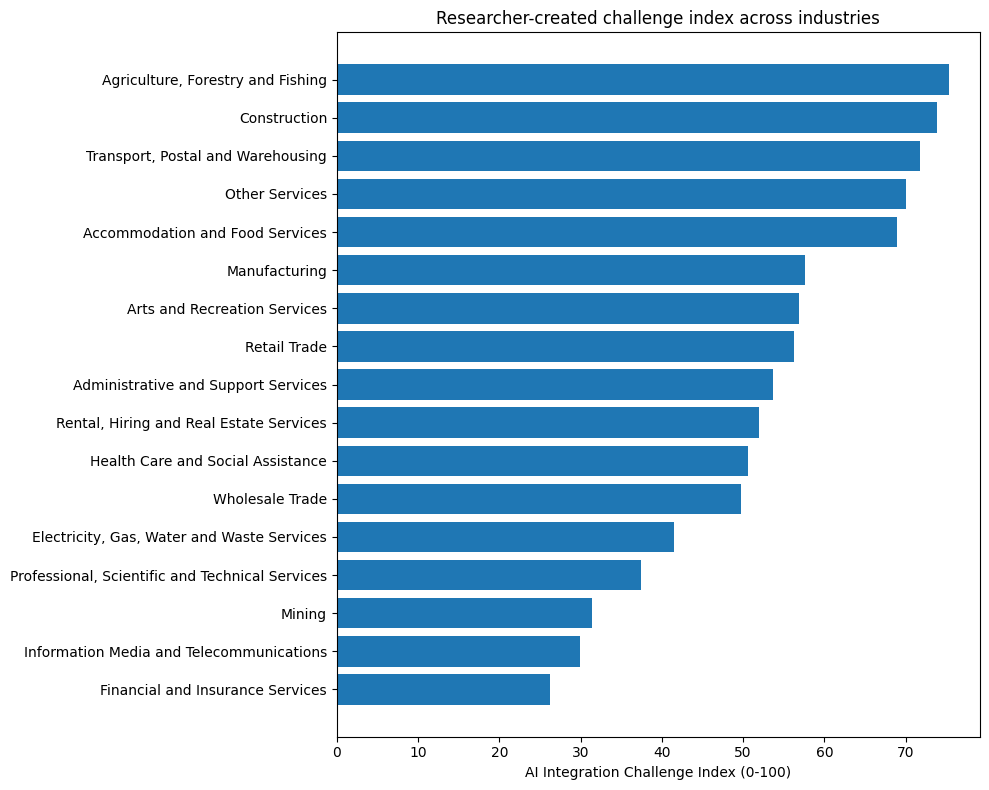

In [14]:
c = challenge.sort_values('challenge_index')
plt.figure(figsize=(10,8))
plt.barh(c['industry'], c['challenge_index'])
plt.xlabel('AI Integration Challenge Index (0-100)')
plt.title('Researcher-created challenge index across industries')
plt.tight_layout()
plt.show()

### Finding 6

Retail Trade recorded a challenge score of **56.3/100**, ranking **8th** among 17 industries when rank 1 denotes the greatest measured challenge. The score places retail in the high-challenge category. It should not be read as a probability of project failure; it is a comparative index showing where capability deficits and operating pressures coexist.

In [15]:
retail_sensitivity = sensitivity[sensitivity['industry']=='Retail Trade'].sort_values('challenge_index')
retail_sensitivity

,scheme,industry,challenge_index,rank_1_highest
57,equal_dimensions,Retail Trade,54.954856,6
23,capability_emphasis,Retail Trade,55.320590,8
6,balanced,Retail Trade,56.272594,8
40,risk_emphasis,Retail Trade,58.902481,7


### Sensitivity interpretation

Retail remains in the middle-to-higher challenge range under all weighting schemes. Its exact rank changes, which confirms that composite-index results depend on defensible but contestable weighting decisions. The stable substantive conclusion is more important than the precise rank: retail has strong digital reach but weaker analytical depth, workforce investment and formal governance.

## 8. Predictive modelling: 2021-22 capability indicators and 2024-25 AI adoption

The target is the published 2024-25 industry AI-use percentage. Predictors are published 2021-22 capability measures. This temporal ordering is preferable to predicting a 2024 outcome from 2024 variables, but the design remains observational and aggregate.

Only 17 industry observations are available. Leave-one-industry-out cross-validation is used so each industry is tested once outside the training set. Four models are compared with a mean-only baseline.

In [16]:
model_metrics.sort_values('mae_pp')

,model,mae_pp,rmse_pp,r2
0,ElasticNet,3.691950,4.691498,0.719339
1,Ridge,3.780258,4.991778,0.682262
2,ExtraTrees,3.896445,5.515646,0.612072
3,RandomForest,4.044753,5.771214,0.575290
4,Mean baseline,6.771626,8.855655,0.000000


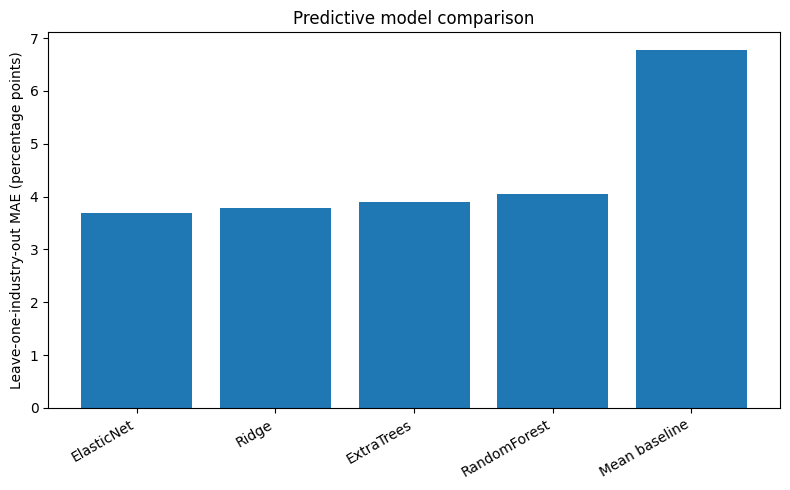

In [17]:
plt.figure(figsize=(8,5))
plot_metrics = model_metrics.sort_values('mae_pp')
plt.bar(plot_metrics['model'], plot_metrics['mae_pp'])
plt.ylabel('Leave-one-industry-out MAE (percentage points)')
plt.title('Predictive model comparison')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Finding 7

The best exploratory model was **ElasticNet**, with a leave-one-industry-out mean absolute error of **3.69 percentage points**, compared with 6.77 percentage points for the mean-only baseline. Its cross-validated R² was **0.72**. This is encouraging for a preliminary model but not sufficient for high-confidence forecasting because the sample contains only 17 aggregate units.

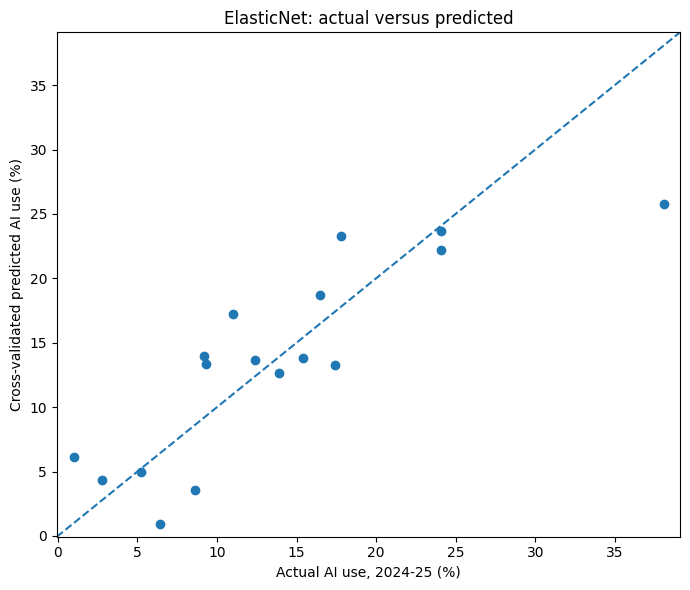

,industry,model,actual_ai_use_2024_25_pct,predicted_ai_use_pct,error_pp
26,Information Media and Telecommunications,ElasticNet,38.1,25.764622,-12.335378
28,"Rental, Hiring and Real Estate Services",ElasticNet,11.0,17.213465,6.213465
18,Mining,ElasticNet,17.8,23.291232,5.491232
21,Construction,ElasticNet,6.4,0.941498,-5.458502
25,"Transport, Postal and Warehousing",ElasticNet,1.0,6.120112,5.120112
33,Other Services,ElasticNet,8.6,3.571676,-5.028324
23,Retail Trade,ElasticNet,9.2,13.961412,4.761412
31,Health Care and Social Assistance,ElasticNet,17.4,13.307289,-4.092711
19,Manufacturing,ElasticNet,9.3,13.317010,4.017010
32,Arts and Recreation Services,ElasticNet,16.5,18.704042,2.204042


In [18]:
best_model = model_metrics.sort_values('mae_pp').iloc[0]['model']
p = model_predictions[model_predictions['model']==best_model]
plt.figure(figsize=(7,6))
plt.scatter(p['actual_ai_use_2024_25_pct'], p['predicted_ai_use_pct'])
limits=[min(p['actual_ai_use_2024_25_pct'].min(),p['predicted_ai_use_pct'].min())-1,
        max(p['actual_ai_use_2024_25_pct'].max(),p['predicted_ai_use_pct'].max())+1]
plt.plot(limits, limits, '--')
plt.xlim(limits); plt.ylim(limits)
plt.xlabel('Actual AI use, 2024-25 (%)')
plt.ylabel('Cross-validated predicted AI use (%)')
plt.title(f'{best_model}: actual versus predicted')
plt.tight_layout()
plt.show()
p.sort_values('error_pp', key=lambda s:s.abs(), ascending=False)

## 9. Responsible factors: coefficients, Gini importance and permutation importance

Three importance views are retained:

- standardised Ridge coefficients indicate direction and relative linear contribution;
- Random Forest Gini importance indicates how often and how strongly variables split the data, but can favour variables with greater variability;
- permutation importance measures the change in model error when a feature is shuffled.

No importance measure establishes causation.

In [19]:
factor_importance.sort_values('absolute_ridge_coefficient', ascending=False)

,feature,ridge_standardised_coefficient,random_forest_gini_importance,random_forest_permutation_importance_mae,pearson_correlation_with_2024_ai_use,absolute_ridge_coefficient
0,fibre_pct,1.224323,0.256368,1.438458,0.890878,1.224323
1,data_analytics_pct,1.068241,0.036894,0.092687,0.755312,1.068241
2,any_ict_management_practice_pct,0.907180,0.198531,1.056380,0.836580,0.907180
3,digital_training_pct,0.853485,0.054965,0.154458,0.776915,0.853485
4,digital_platforms_pct,0.795822,0.061172,0.218740,0.754522,0.795822
5,cloud_pct,0.703037,0.117999,0.628074,0.781133,0.703037
6,crm_pct,0.631494,0.070642,0.379722,0.676432,0.631494
7,measured_digital_contribution_pct,0.497809,0.019629,0.024875,0.654068,0.497809
8,any_cyber_measure_pct,0.494924,0.118661,0.444807,0.660989,0.494924
9,internet_sufficient_pct,-0.415670,0.012601,0.047004,-0.143696,0.415670


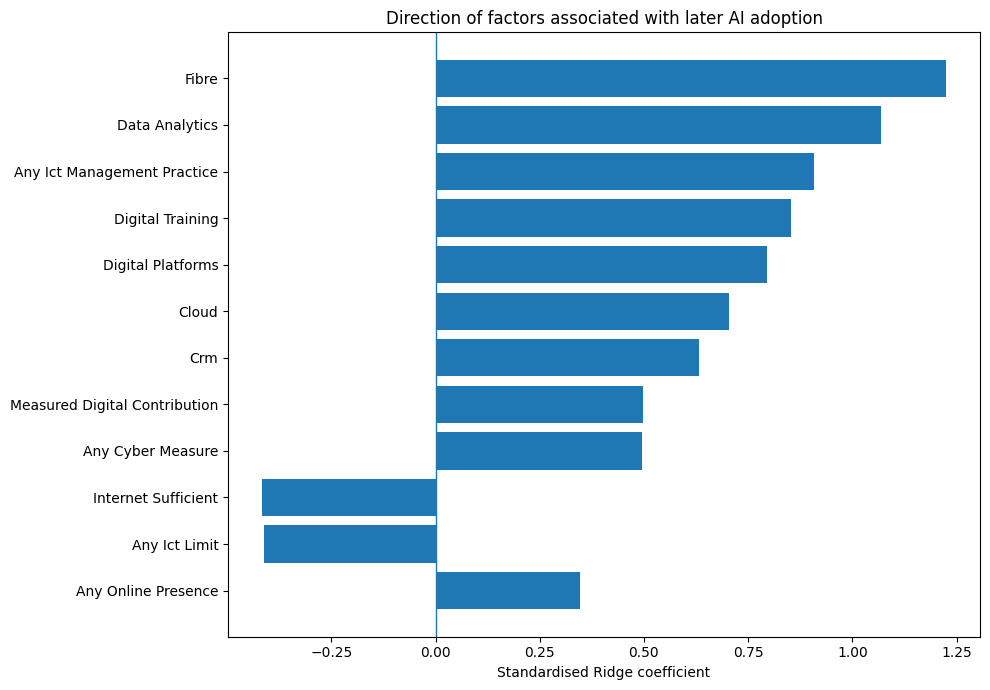

In [20]:
f = factor_importance.sort_values('absolute_ridge_coefficient').tail(12)
plt.figure(figsize=(10,7))
plt.barh(f['feature'].str.replace('_pct','').str.replace('_',' ').str.title(), f['ridge_standardised_coefficient'])
plt.axvline(0, linewidth=1)
plt.xlabel('Standardised Ridge coefficient')
plt.title('Direction of factors associated with later AI adoption')
plt.tight_layout()
plt.show()

### Finding 8

The most consistently positive predictors were fibre connectivity, data analytics, ICT management practices, digital training, digital platforms and cloud use. ICT limitations and skill shortages had negative coefficients. These results suggest that later AI adoption is associated with a bundle of complementary capabilities rather than a single technology.

Fibre connectivity should not be interpreted as a direct cause of AI adoption. It is likely a proxy for digital infrastructure, organisational scale, location and investment capacity. The strong result is therefore best interpreted as evidence that infrastructure and management maturity co-occur with AI adoption.

## 10. National SME AI Pulse triangulation

In [21]:
naic[['period','category','measure','value_pct','denominator']]

,period,category,measure,value_pct,denominator
0,2025-09 to 2025-11,AI adoption,SMEs reporting some level of AI adoption,45.0,percent of SMEs
1,2025-12 to 2026-02,AI adoption,SMEs reporting some level of AI adoption,43.0,percent of SMEs
2,2026-02,AI adoption,SMEs reporting some level of AI adoption,44.0,percent of SMEs
3,2025-12 to 2026-02,Non-adoption barrier,Distrust in AI decisions or preference for hum...,65.0,percent of non-adopting SMEs (approximately)
4,2025-12 to 2026-02,Non-adoption barrier,AI perceived as not relevant,54.0,percent of non-adopting SMEs
5,2025-12 to 2026-02,Non-adoption barrier,Do not know how to use AI,19.0,percent of SMEs
6,2025-12 to 2026-02,AI application,Content generation,54.0,percent of adopters/current or planned users
7,2025-12 to 2026-02,AI application,Data analytics,54.0,percent of adopters/current or planned users
8,2025-12 to 2026-02,AI application,Cybersecurity and threat detection,48.0,percent of adopters/current or planned users
9,2025-12 to 2026-02,Responsible AI practice,Checking AI outputs before customer impact,50.0,percent of current AI users (approximately)


### Finding 9

The National AI Centre data shows that trust, perceived relevance and uncertainty about how to begin remain major adoption barriers. Content generation and data analytics were the most commonly reported applications among adopters or intended adopters. These findings are consistent with the ABS pattern: AI adoption can grow while formal governance, advanced analytics and workforce preparation remain incomplete.

The 43% SME Pulse figure must not be compared directly with the ABS 12% all-business or 9% retail values as if they measure the same construct. The surveys differ in scope, respondent population, reference period and definition of adoption.

## 11. Retail operating context: economic scale, business churn and survival

In [22]:
annual_retail[['financial_year','employment_000','total_income_m','operating_profit_m','industry_value_added_m','profit_margin_pct','iva_per_employee_000','income_growth_pct','employment_growth_pct']]

,financial_year,employment_000,total_income_m,operating_profit_m,industry_value_added_m,profit_margin_pct,iva_per_employee_000,income_growth_pct,employment_growth_pct
0,2006-07,1183.7,304880.0,16461.0,52818.0,5.399173,44.621103,NaN,NaN
1,2007-08,1252.1,319037.0,15751.0,56558.0,4.937045,45.170514,4.643466,5.778491
2,2008-09,1259.8,345930.0,17503.0,60325.0,5.059694,47.884585,8.429430,0.614967
3,2009-10,1297.0,357084.0,18978.0,63863.0,5.314716,49.239013,3.224352,2.952850
4,2010-11,1346.0,372975.0,19860.0,67779.0,5.324754,50.355869,4.450213,3.777949
5,2011-12,1307.1,380368.0,19504.0,70603.0,5.127666,54.014995,1.982170,-2.890045
6,2012-13,1319.6,380726.0,19417.0,70618.0,5.099993,53.514701,0.094119,0.956316
7,2013-14,1278.0,386619.0,18307.0,70143.0,4.735153,54.884977,1.547832,-3.152470
8,2014-15,1291.6,389935.0,18724.0,71481.0,4.801826,55.342985,0.857692,1.064163
9,2015-16,1299.4,406772.0,17345.0,73556.0,4.264059,56.607665,4.317899,0.603902


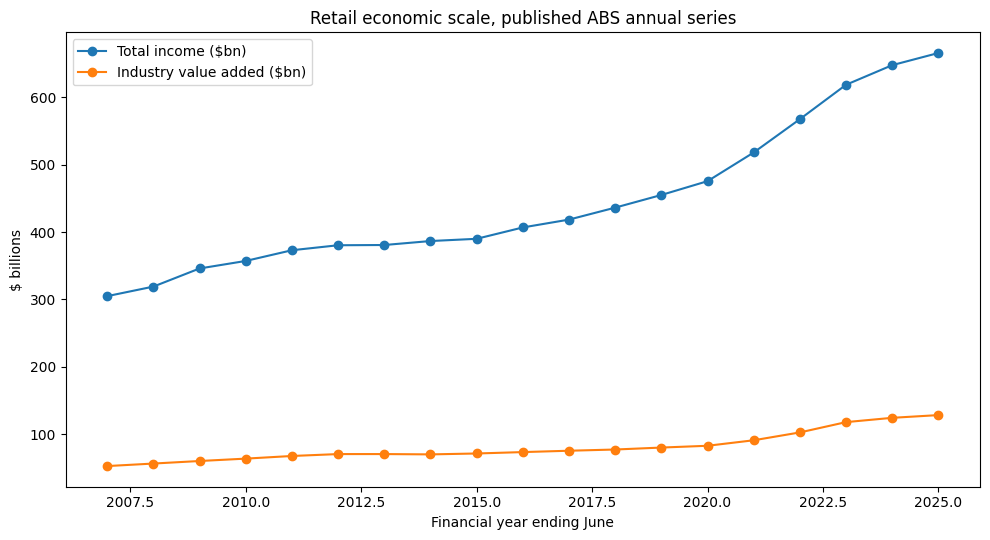

In [23]:
plt.figure(figsize=(10,5.5))
plt.plot(annual_retail['date'].dt.year, annual_retail['total_income_m']/1000, marker='o', label='Total income ($bn)')
plt.plot(annual_retail['date'].dt.year, annual_retail['industry_value_added_m']/1000, marker='o', label='Industry value added ($bn)')
plt.xlabel('Financial year ending June')
plt.ylabel('$ billions')
plt.title('Retail economic scale, published ABS annual series')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
business_dynamics

,operating_start,entries_births,entries_other,entries_total,exits_cancellations,exits_other,exits_total,operating_end,net_change,percentage_change,entry_rate,exit_rate,period
0,139850.0,20058.0,5482.0,25540.0,14172.0,2108.0,16280.0,149110.0,9260.0,6.6,18.3,11.6,2020-21
1,149110.0,21535.0,6354.0,27889.0,16114.0,3311.0,19425.0,157574.0,8464.0,5.7,18.7,13.0,2021-22
2,157574.0,18136.0,5640.0,23776.0,20294.0,3810.0,24104.0,157246.0,-328.0,-0.2,15.1,15.3,2022-23
3,157246.0,18041.0,6469.0,24510.0,20737.0,4081.0,24818.0,156938.0,-308.0,-0.2,15.6,15.8,2023-24


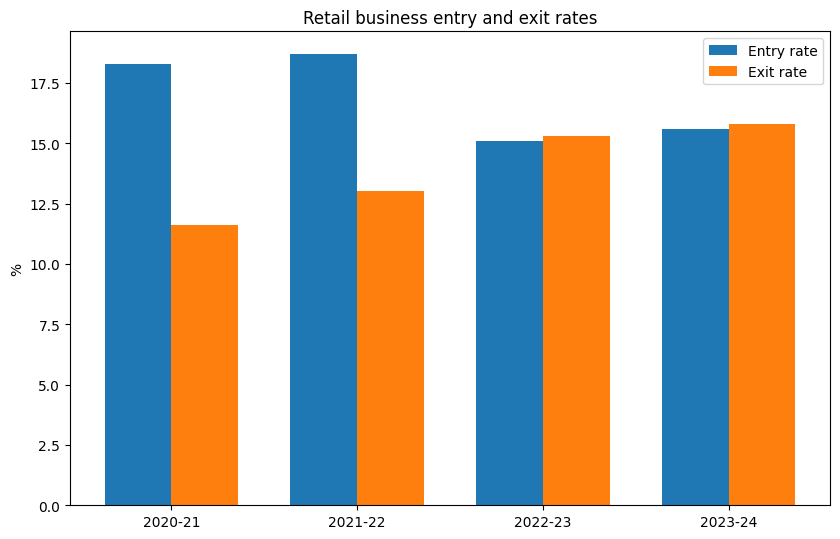

,cohort,horizon,survival_rate_pct
0,Businesses operating June 2020,1 year,88.4
1,Businesses operating June 2020,2 years,78.7
2,Businesses operating June 2020,3 years,70.0
3,Businesses operating June 2020,4 years,62.3
4,Retail entries in 2020-21,1 year,76.7
5,Retail entries in 2020-21,2 years,59.1
6,Retail entries in 2020-21,3 years,48.5


In [25]:
x=np.arange(len(business_dynamics))
plt.figure(figsize=(8.5,5.5))
plt.bar(x-0.18,business_dynamics['entry_rate'],width=0.36,label='Entry rate')
plt.bar(x+0.18,business_dynamics['exit_rate'],width=0.36,label='Exit rate')
plt.xticks(x,business_dynamics['period'])
plt.ylabel('%')
plt.title('Retail business entry and exit rates')
plt.legend()
plt.tight_layout()
plt.show()
business_survival

### Finding 10

The number of actively operating retail businesses reached **156,938** at June 2024, but exits exceeded entries in both 2022-23 and 2023-24. The four-year survival rate for retail businesses operating in June 2020 was **62.3%**, while the three-year survival rate of 2020-21 retail entries was lower.

This operating context matters because investment capacity and tolerance for failed experiments differ across firms. A responsible implementation framework should therefore recommend low-risk, modular use cases for smaller retailers and stronger portfolio governance for larger firms.

## 12. Future scenarios for retail AI adoption

The scenario file applies conservative, base and accelerated continuation factors to the observed ABS change between 2021-22 and 2024-25. Caps prevent implausible indefinite linear growth. These are planning scenarios, not forecasts, because only two comparable retail AI observations are available.

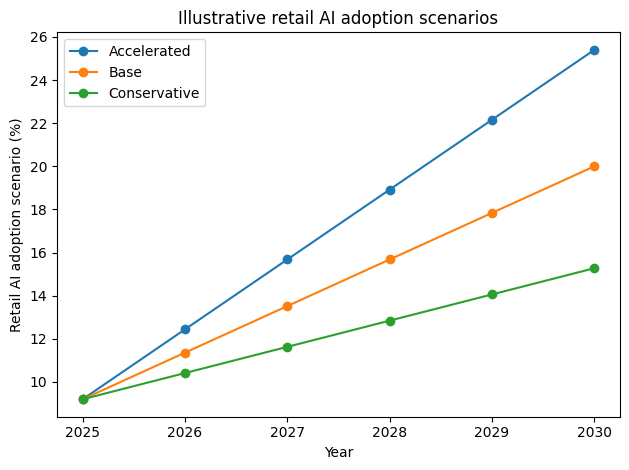

,year,scenario,retail_ai_adoption_pct,method_note
0,2025,Conservative,9.200,Transparent scenario extrapolation from two AB...
1,2025,Base,9.200,Transparent scenario extrapolation from two AB...
2,2025,Accelerated,9.200,Transparent scenario extrapolation from two AB...
3,2026,Conservative,10.415,Transparent scenario extrapolation from two AB...
4,2026,Base,11.360,Transparent scenario extrapolation from two AB...
5,2026,Accelerated,12.440,Transparent scenario extrapolation from two AB...
6,2027,Conservative,11.630,Transparent scenario extrapolation from two AB...
7,2027,Base,13.520,Transparent scenario extrapolation from two AB...
8,2027,Accelerated,15.680,Transparent scenario extrapolation from two AB...
9,2028,Conservative,12.845,Transparent scenario extrapolation from two AB...


In [26]:
for name,g in scenarios.groupby('scenario'):
    plt.plot(g['year'],g['retail_ai_adoption_pct'],marker='o',label=name)
plt.xlabel('Year')
plt.ylabel('Retail AI adoption scenario (%)')
plt.title('Illustrative retail AI adoption scenarios')
plt.legend()
plt.tight_layout()
plt.show()
scenarios

### Scenario interpretation

All three paths imply continued growth, but the range widens quickly. The main decision value is not the exact percentage. The scenarios show that capability investment needs to occur before adoption reaches a larger share of the sector. Otherwise skills, governance and cyber controls may lag deployment.

## 13. Integrated findings and management implications

The evidence supports eight connected conclusions:

1. Retail AI adoption is accelerating from a low base.
2. Retail has strong online reach and cloud adoption but limited advanced analytics.
3. Skills and uncertainty about value remain material constraints.
4. Digital training and formal governance are not keeping pace with adoption.
5. Cyber incidents are common enough to make resilience a scaling condition.
6. Innovation produces value, but benefits require deliberate measurement.
7. AI adoption is predicted more effectively by a bundle of digital, managerial and workforce capabilities than by any isolated measure.
8. Small business churn and survival patterns require proportionate implementation pathways.

These findings support a capability-based framework with six pillars: strategy and value, data and systems, people and change, responsible governance, cyber resilience, and measurement and learning. Implementation should proceed through discovery, preparation, pilot, scale and assurance stages.

## 14. Limitations

- The primary model has only 17 industry observations.
- ABS waves are repeated cross-sections, not a panel of the same businesses.
- Aggregate industry relationships cannot be generalised to an individual retailer.
- Survey questions and the redesigned 2024-25 BCS require caution in longitudinal comparison.
- The composite index depends on scaling and weighting choices.
- The National AI Centre and ABS adoption measures are not directly equivalent.
- Scenario projections are transparent extrapolations, not validated forecasts.
- Feature importance identifies predictive contribution, not causal responsibility.

## 15. Files produced for verification and reuse

- `published_secondary_data_long_expanded.csv`: source-linked audit table;
- `industry_2021_22_expanded.csv` and `industry_2024_25_expanded.csv`: modelling tables;
- `ai_integration_readiness_challenge_index.csv`: composite dimensions and index;
- `challenge_index_sensitivity.csv`: alternative weighting results;
- `predictive_model_metrics.csv`, `predictive_model_predictions.csv` and `predictive_factor_importance.csv`: model audit outputs;
- `retail_monthly_turnover_1982_2025.csv`, `retail_annual_industry_performance_2007_2025.csv`, `retail_business_entries_exits_2020_2024.csv`: retail context;
- `source_register.csv` and `data_dictionary.csv`: provenance documentation.

## Conclusion

Published secondary data supports a meaningful analytical study of AI integration in Australian retail. The strongest conclusion is not that one variable determines adoption. AI adoption is associated with complementary infrastructure, analytical capability, management practice, training and governance. Retail's digital reach creates an opportunity, but the sector's challenge profile indicates that responsible scaling requires coordinated capability investment. The predictive results are useful as preliminary evidence and a basis for future primary research, not as a claim of causal certainty.